# Image Analysis

This notebook analyzes image-level characteristics of the dermoscopic dataset. We examine dimensions, color distributions, and quality factors that inform preprocessing decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import json
from tqdm import tqdm

In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)

In [3]:
IMAGES_DIR = RAW_DATA_DIR / "ISIC_2019_Training_Input"
labels_path = DATA_DIR / "labels_with_class.csv"

df = pd.read_csv(labels_path)
image_files = list(IMAGES_DIR.glob("*.jpg"))

print(f"Found {len(image_files)} images")

Found 25331 images


In [4]:
# Sample subset for analysis (analyzing all images would be time-consuming)
np.random.seed(42)
sample_size = min(500, len(image_files))
sample_files = np.random.choice(image_files, size=sample_size, replace=False)

print(f"Analyzing {sample_size} sample images")

Analyzing 500 sample images


In [5]:
dimensions = []

for img_path in tqdm(sample_files, desc="Collecting dimensions"):
    img = Image.open(img_path)
    width, height = img.size
    dimensions.append({
        "filename": img_path.name,
        "width": width,
        "height": height,
        "aspect_ratio": width / height
    })

df_dims = pd.DataFrame(dimensions)

In [6]:
print("Dimension Statistics:")
print(df_dims[["width", "height", "aspect_ratio"]].describe())

Dimension Statistics:
             width       height  aspect_ratio
count   500.000000   500.000000    500.000000
mean    856.658000   755.822000      1.190810
std     206.004049   266.697284      0.187255
min     600.000000   450.000000      1.000000
25%     600.000000   450.000000      1.000000
50%    1024.000000   768.000000      1.333333
75%    1024.000000  1024.000000      1.333333
max    1024.000000  1024.000000      1.517037


The dimension statistics reveal image size variability. Understanding this helps determine appropriate resizing strategy.

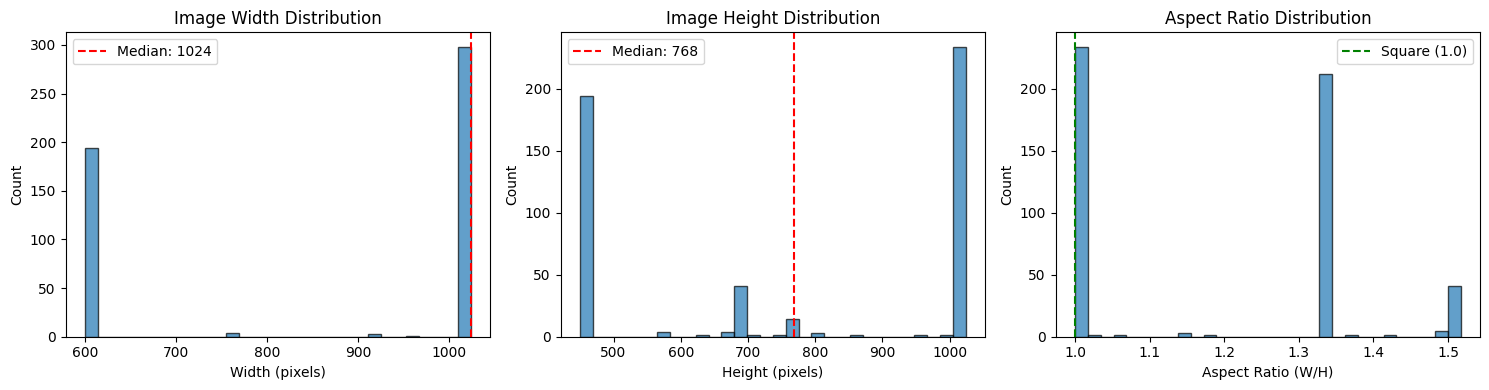

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_dims["width"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Count")
axes[0].set_title("Image Width Distribution")
axes[0].axvline(df_dims["width"].median(), color="red", linestyle="--", label=f"Median: {df_dims['width'].median():.0f}")
axes[0].legend()

axes[1].hist(df_dims["height"], bins=30, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Count")
axes[1].set_title("Image Height Distribution")
axes[1].axvline(df_dims["height"].median(), color="red", linestyle="--", label=f"Median: {df_dims['height'].median():.0f}")
axes[1].legend()

axes[2].hist(df_dims["aspect_ratio"], bins=30, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_ylabel("Count")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(1.0, color="green", linestyle="--", label="Square (1.0)")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dimension_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
unique_sizes = df_dims.groupby(["width", "height"]).size().reset_index(name="count")
unique_sizes = unique_sizes.sort_values("count", ascending=False)

print(f"Number of unique dimension combinations: {len(unique_sizes)}")
print("\nTop 10 most common dimensions:")
print(unique_sizes.head(10))

Number of unique dimension combinations: 22

Top 10 most common dimensions:
    width  height  count
21   1024    1024    234
0     600     450    194
9    1024     680     33
17   1024     768     11
1     767     576      4
2     919     802      3
13   1024     685      3
16   1024     764      2
11   1024     682      2
8    1024     679      2


Multiple unique dimensions exist, confirming the need for resizing during preprocessing. The target size of 256x256 will normalize all images.

In [9]:
def compute_color_stats(img_path):
    """Compute color statistics for an image."""
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    stats = {}
    for i, channel in enumerate(["R", "G", "B"]):
        ch = img_rgb[:, :, i].flatten()
        stats[f"{channel}_mean"] = ch.mean()
        stats[f"{channel}_std"] = ch.std()
        stats[f"{channel}_min"] = ch.min()
        stats[f"{channel}_max"] = ch.max()
    
    # Overall brightness
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    stats["brightness_mean"] = gray.mean()
    stats["brightness_std"] = gray.std()
    
    return stats

In [10]:
color_stats = []

for img_path in tqdm(sample_files[:200], desc="Computing color statistics"):
    stats = compute_color_stats(img_path)
    stats["filename"] = img_path.name
    color_stats.append(stats)

df_colors = pd.DataFrame(color_stats)


Computing color statistics:   0%|                       | 0/200 [00:00<?, ?it/s]


Computing color statistics:   4%|▋              | 9/200 [00:00<00:02, 88.90it/s]


Computing color statistics:   9%|█▎            | 18/200 [00:00<00:02, 71.86it/s]


Computing color statistics:  13%|█▊            | 26/200 [00:00<00:02, 61.81it/s]


Computing color statistics:  17%|██▍           | 34/200 [00:00<00:02, 67.05it/s]

...


Computing color statistics:  86%|███████████  | 171/200 [00:02<00:00, 72.04it/s]


Computing color statistics:  90%|███████████▋ | 179/200 [00:02<00:00, 71.52it/s]


Computing color statistics:  94%|████████████▏| 187/200 [00:02<00:00, 72.23it/s]


Computing color statistics:  98%|████████████▋| 196/200 [00:02<00:00, 76.93it/s]


Computing color statistics: 100%|█████████████| 200/200 [00:02<00:00, 72.33it/s]

In [11]:
print("Color Channel Statistics (across sample):")
print(df_colors[["R_mean", "G_mean", "B_mean", "brightness_mean"]].describe())

Color Channel Statistics (across sample):
           R_mean      G_mean      B_mean  brightness_mean
count  200.000000  200.000000  200.000000       200.000000
mean   172.802811  135.157869  134.291338       146.321571
std     36.739857   29.224782   31.409674        29.131225
min     56.555230   47.154731   44.285063        52.925386
25%    156.076406  120.420398  115.321333       132.456228
50%    176.344645  136.691139  136.520812       149.601007
75%    195.142507  154.705101  156.411144       166.978476
max    247.215019  187.162987  198.465733       197.511403


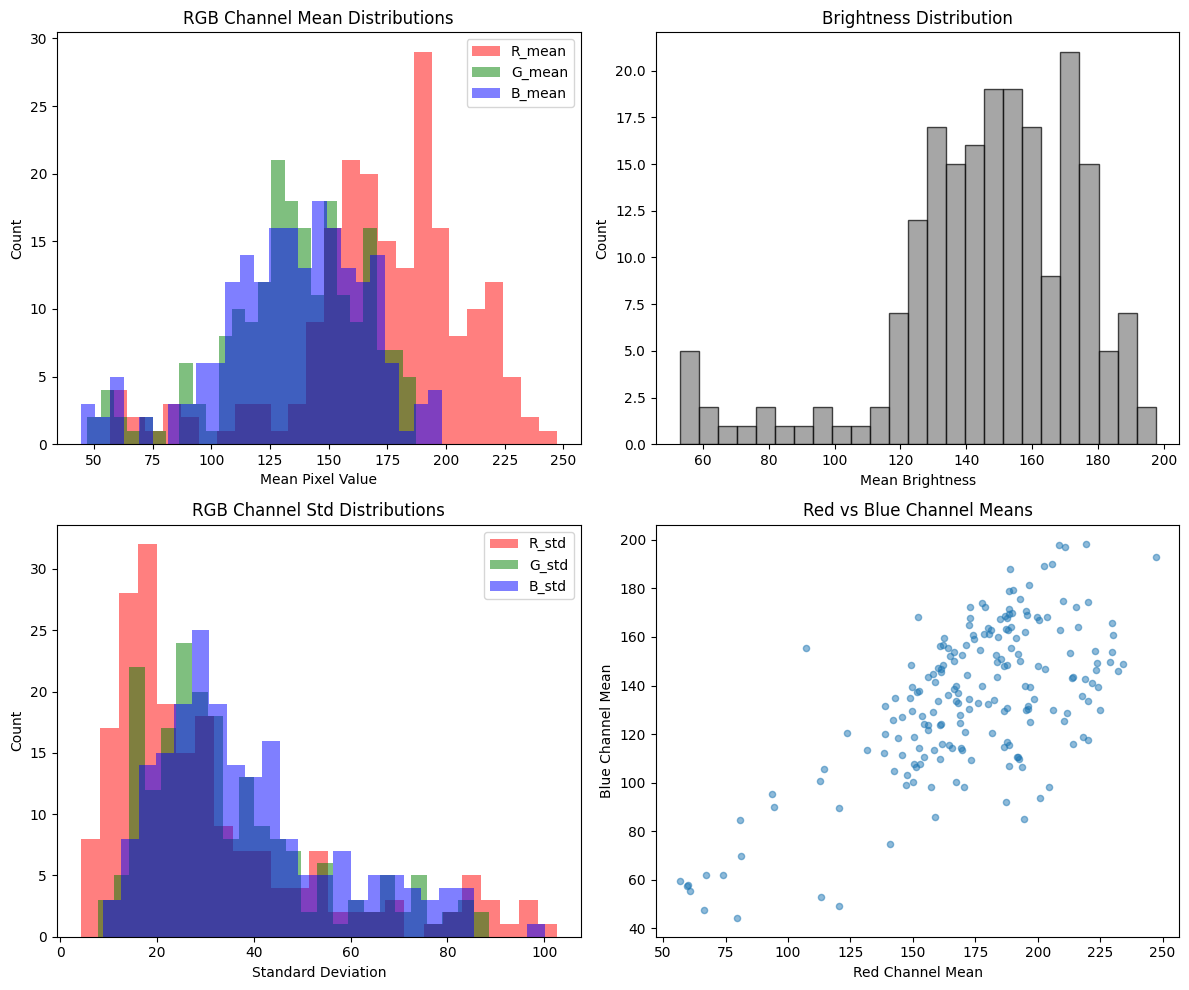

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors_list = ["red", "green", "blue"]
for i, (col, color) in enumerate(zip(["R_mean", "G_mean", "B_mean"], colors_list)):
    axes[0, 0].hist(df_colors[col], bins=25, alpha=0.5, label=col, color=color)
axes[0, 0].set_xlabel("Mean Pixel Value")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("RGB Channel Mean Distributions")
axes[0, 0].legend()

axes[0, 1].hist(df_colors["brightness_mean"], bins=25, edgecolor="black", alpha=0.7, color="gray")
axes[0, 1].set_xlabel("Mean Brightness")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Brightness Distribution")

for i, (col, color) in enumerate(zip(["R_std", "G_std", "B_std"], colors_list)):
    axes[1, 0].hist(df_colors[col], bins=25, alpha=0.5, label=col, color=color)
axes[1, 0].set_xlabel("Standard Deviation")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("RGB Channel Std Distributions")
axes[1, 0].legend()

axes[1, 1].scatter(df_colors["R_mean"], df_colors["B_mean"], alpha=0.5, s=20)
axes[1, 1].set_xlabel("Red Channel Mean")
axes[1, 1].set_ylabel("Blue Channel Mean")
axes[1, 1].set_title("Red vs Blue Channel Means")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "color_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Color analysis reveals:
- Red channel tends to have higher mean values (typical for skin tones)
- Brightness varies significantly across images (supports need for CLAHE)
- Standard deviation varies, indicating different contrast levels

In [13]:
def analyze_potential_artifacts(img_path):
    """Basic analysis for potential artifacts like hair."""
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Dark line detection (potential hair)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    
    dark_pixels = np.sum(blackhat > 10)
    total_pixels = gray.size
    dark_ratio = dark_pixels / total_pixels
    
    return {
        "filename": img_path.name,
        "dark_line_ratio": dark_ratio,
        "potential_hair": dark_ratio > 0.02
    }

In [14]:
artifact_analysis = []

for img_path in tqdm(sample_files[:200], desc="Analyzing artifacts"):
    result = analyze_potential_artifacts(img_path)
    artifact_analysis.append(result)

df_artifacts = pd.DataFrame(artifact_analysis)


Analyzing artifacts:   0%|                              | 0/200 [00:00<?, ?it/s]


Analyzing artifacts:  10%|█▉                  | 19/200 [00:00<00:00, 186.25it/s]


Analyzing artifacts:  19%|███▊                | 38/200 [00:00<00:00, 176.11it/s]


Analyzing artifacts:  28%|█████▌              | 56/200 [00:00<00:00, 177.60it/s]


Analyzing artifacts:  38%|███████▌            | 76/200 [00:00<00:00, 181.75it/s]

...


Analyzing artifacts:  68%|████████████▉      | 136/200 [00:00<00:00, 191.72it/s]


Analyzing artifacts:  78%|██████████████▊    | 156/200 [00:00<00:00, 189.16it/s]


Analyzing artifacts:  88%|████████████████▋  | 176/200 [00:00<00:00, 189.71it/s]


Analyzing artifacts:  98%|██████████████████▋| 197/200 [00:01<00:00, 194.47it/s]


Analyzing artifacts: 100%|███████████████████| 200/200 [00:01<00:00, 187.69it/s]

In [15]:
hair_count = df_artifacts["potential_hair"].sum()
total_analyzed = len(df_artifacts)

print(f"Images with potential hair artifacts: {hair_count}/{total_analyzed} ({hair_count/total_analyzed*100:.1f}%)")

Images with potential hair artifacts: 176/200 (88.0%)


A notable portion of images contain potential hair artifacts. This justifies including hair removal in the preprocessing pipeline.

In [16]:
# Get class labels for sampled images
sample_names = [f.stem for f in sample_files[:200]]
sample_df = df[df["image"].isin(sample_names)].copy()
    
# Merge with color stats
df_colors["image"] = df_colors["filename"].str.replace(".jpg", "", regex=False)
merged = sample_df.merge(df_colors, on="image", how="inner")
    
print(f"Merged {len(merged)} samples for per-class analysis")

Merged 200 samples for per-class analysis


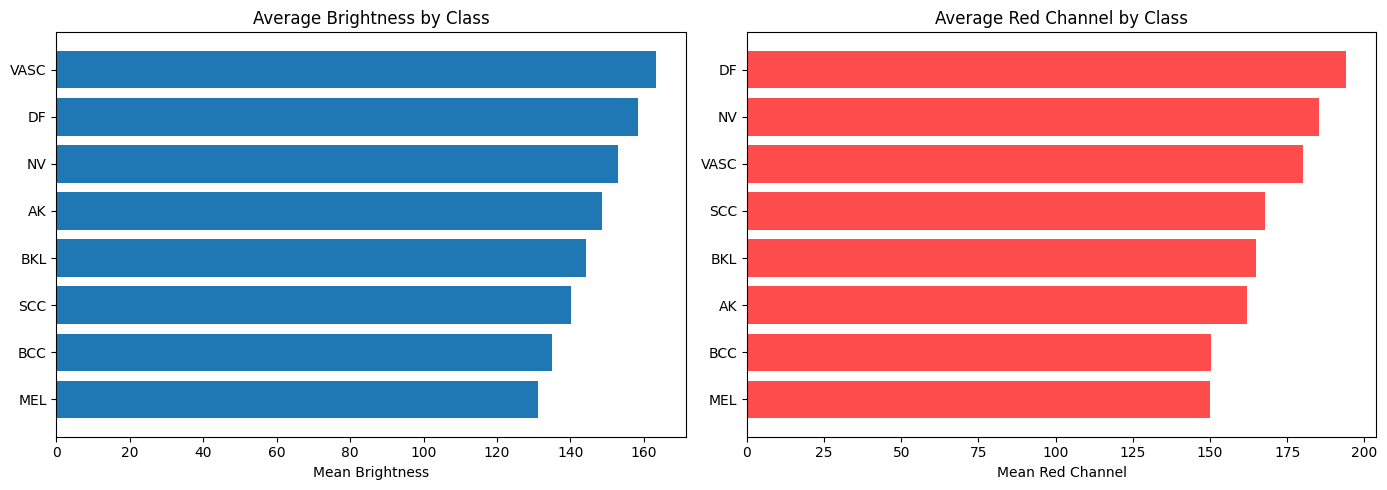

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
class_brightness = merged.groupby("class_label")["brightness_mean"].mean().sort_values()
axes[0].barh(class_brightness.index, class_brightness.values)
axes[0].set_xlabel("Mean Brightness")
axes[0].set_title("Average Brightness by Class")
    
class_red = merged.groupby("class_label")["R_mean"].mean().sort_values()
axes[1].barh(class_red.index, class_red.values, color="red", alpha=0.7)
axes[1].set_xlabel("Mean Red Channel")
axes[1].set_title("Average Red Channel by Class")
    
plt.tight_layout()
plt.savefig(RESULTS_DIR / "color_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

Per-class color analysis may reveal if certain lesion types have distinctive color profiles. However, color alone is unlikely to be sufficient for classification due to overlap.

In [18]:
image_analysis_summary = {
    "sample_size": sample_size,
    "dimension_stats": {
        "width_median": float(df_dims["width"].median()),
        "height_median": float(df_dims["height"].median()),
        "unique_dimensions": len(unique_sizes)
    },
    "color_stats": {
        "brightness_mean": float(df_colors["brightness_mean"].mean()),
        "brightness_std": float(df_colors["brightness_mean"].std()),
        "red_mean": float(df_colors["R_mean"].mean()),
        "green_mean": float(df_colors["G_mean"].mean()),
        "blue_mean": float(df_colors["B_mean"].mean())
    },
    "artifact_analysis": {
        "potential_hair_percentage": float(hair_count / total_analyzed * 100)
    }
}

with open(RESULTS_DIR / "image_analysis_summary.json", "w") as f:
    json.dump(image_analysis_summary, f, indent=2)
    
print("Image analysis summary saved.")

Image analysis summary saved.
